# 01 Exploration: CRMLS Sold Properties (Single-Family Residential)

**IDX Exchange Data Science Internship, Week 2 deliverable**

**Goal.** Understand the structure, quality and main patterns of the CRMLS sold data before preprocessing (Week 3) and modeling (Week 4+). The end task is predicting `ClosePrice` for a single-family home from characteristics that are known *before* any sale.

**Data snapshot.** Monthly `CRMLSSold<YYYYMM>.csv` files copied from the IDX Exchange FTP (`/raw/California`), covering closings from **January 2024 through April 2026** (28 months). Field definitions follow *Trestle Property MetaData.pdf*. Raw files live in `csv/` and are **not** committed to the repository.

**Scope.** Per the task document, analysis is restricted to `PropertyType == "Residential"` and `PropertySubType == "SingleFamilyResidence"`.

**What this notebook does not do.** It flags data problems but does not remove them. Cleaning, outlier thresholds (fit on the training window only) and the chronological train/test split belong to Week 3, so nothing here should be read as a final filtering decision. Since the repo is public, no raw rows are printed (the data contains agent names, emails and addresses); only aggregates are shown.

**Contents**
1. Load and combine the monthly files
2. Property mix and the SFR filter
3. Column inventory and missingness
4. Data quality checks
5. Target: `ClosePrice`
6. Core features: living area, bedrooms, bathrooms, lot size, year built
7. Relationships with `ClosePrice` (and a first leakage check)
8. Geography
9. Time trends and seasonality
10. Key findings and next steps

In [26]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import contextily as ctx

RANDOM_STATE = 42

# Works whether the notebook is run from notebooks/ or from the repo root
DATA_DIR = next(p for p in [Path('../csv'), Path('csv')] if p.exists())

# California bounding box, used to flag impossible coordinates
CA_LAT, CA_LON = (32.4, 42.1), (-124.6, -114.1)

# Chart style: a single blue for single-series charts, gray for context,
# hairline solid grid, no top/right spines
BLUE, GRAY, LIGHT_GRAY = '#2a78d6', '#a3a29d', '#e4e3df'
plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': '#fcfcfb',
    'axes.facecolor': '#fcfcfb',
    'axes.edgecolor': '#c9c8c3',
    'axes.linewidth': 0.8,
    'axes.grid': True,
    'grid.color': LIGHT_GRAY,
    'grid.linewidth': 0.6,
    'axes.axisbelow': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.titlelocation': 'left',
    'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e',
    'ytick.color': '#52514e',
    'font.size': 9.5,
    'axes.prop_cycle': plt.cycler(color=[BLUE]),
})

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


def money(x, _=None):
    # Axis formatter: $850K, $1.2M
    return f'${x / 1e6:.1f}M' if abs(x) >= 1e6 else f'${x / 1e3:.0f}K'


# Charts are also written to reports/figures/ for the findings memo
FIG_DIR = DATA_DIR.parent / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(name):
    plt.savefig(FIG_DIR / f'{name}.png', dpi=130, bbox_inches='tight')


def pct(n, d):
    return f'{100 * n / d:.2f}%'

## 1. Load and combine the monthly files

Each file holds one calendar month of closings. A `SourceMonth` column records which file a row came from, so later checks can tell file-level quirks apart from real data patterns.

In [27]:
files = sorted(DATA_DIR.glob('CRMLSSold*.csv'))
frames = []
for f in files:
    d = pd.read_csv(f, low_memory=False)
    d['SourceMonth'] = re.search(r'(\d{6})', f.name).group(1)
    frames.append(d)

raw = pd.concat(frames, ignore_index=True)
print(f'{len(files)} files: {files[0].name} ... {files[-1].name}')
print(f'Combined: {raw.shape[0]:,} rows x {raw.shape[1]} columns')
print('MlsStatus values:', raw['MlsStatus'].value_counts().to_dict())

28 files: CRMLSSold202401_filled.csv ... CRMLSSold202604.csv
Combined: 615,707 rows x 85 columns
MlsStatus values: {'Closed': 615707}


The files do **not** share one schema. The columns below are present in only some months. Files with a `_filled` suffix carry two extra flags (`latfilled`, `lonfilled`) that appear to mark coordinates that were back-filled (geocoded) rather than entered by the agent.

In [28]:
months = [fr['SourceMonth'].iat[0] for fr in frames]
presence = pd.DataFrame(
    {m: pd.Series(True, index=fr.columns) for m, fr in zip(months, frames)}
).fillna(False).drop(index='SourceMonth')

partial = presence[~presence.all(axis=1)]
schema = pd.DataFrame({
    'files_present': partial.sum(axis=1),
    'first_month': partial.apply(lambda r: r[r].index.min(), axis=1),
    'last_month': partial.apply(lambda r: r[r].index.max(), axis=1),
}).sort_values(['first_month', 'files_present'])
print(f'{presence.all(axis=1).sum()} columns appear in every file; {len(partial)} do not:')
schema

76 columns appear in every file; 8 do not:


,files_present,first_month,last_month
BuyerAgencyCompensation,4,202401,202404
BuyerAgencyCompensationType,4,202401,202404
latfilled,7,202401,202501
lonfilled,7,202401,202501
BuyerAgentAOR,24,202405,202604
ListAgentAOR,24,202405,202604
OriginatingSystemName,3,202602,202604
OriginatingSystemSubName,3,202602,202604


## 2. Property mix and the SFR filter

The sold feed covers every property type, including leases, land and commercial. The task restricts us to single-family residences, so it helps to see how much of the feed that is.

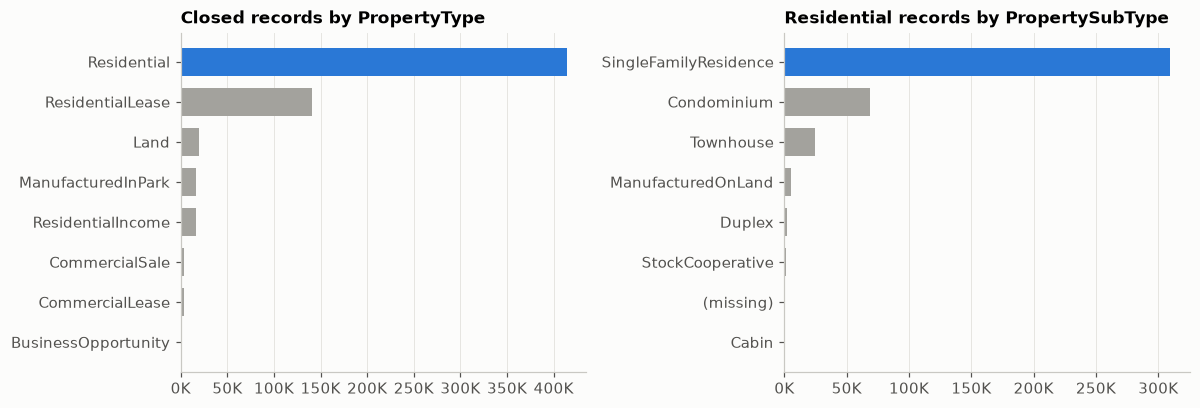

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

pt = raw['PropertyType'].value_counts().sort_values()
axes[0].barh(pt.index, pt.values, color=[BLUE if i == 'Residential' else GRAY for i in pt.index], height=0.7)
axes[0].set_title('Closed records by PropertyType')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x / 1e3:.0f}K'))
axes[0].grid(axis='y', visible=False)

st = (raw.loc[raw['PropertyType'] == 'Residential', 'PropertySubType']
      .fillna('(missing)').value_counts().head(8).sort_values())
axes[1].barh(st.index, st.values, color=[BLUE if i == 'SingleFamilyResidence' else GRAY for i in st.index], height=0.7)
axes[1].set_title('Residential records by PropertySubType')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x / 1e3:.0f}K'))
axes[1].grid(axis='y', visible=False)

plt.tight_layout()
save_fig('property_mix')
plt.show()

In [30]:
filter_log = [('All closed records', len(raw))]
res = raw[raw['PropertyType'] == 'Residential']
filter_log.append(('PropertyType == Residential', len(res)))
sfr = res[res['PropertySubType'] == 'SingleFamilyResidence'].copy()
filter_log.append(('PropertySubType == SingleFamilyResidence', len(sfr)))

log = pd.DataFrame(filter_log, columns=['step', 'rows'])
log['dropped'] = (-log['rows'].diff()).fillna(0).astype(int)
log['pct_of_all'] = (100 * log['rows'] / len(raw)).round(1)
log

,step,rows,dropped,pct_of_all
0,All closed records,615707,0,100.00
1,PropertyType == Residential,414054,201653,67.20
2,PropertySubType == SingleFamilyResidence,309735,104319,50.30


Light type conversion so the rest of the notebook can work with dates, booleans and derived helpers. Nothing is dropped here.

In [31]:
for c in ['CloseDate', 'ListingContractDate', 'PurchaseContractDate', 'ContractStatusChangeDate']:
    sfr[c] = pd.to_datetime(sfr[c], errors='coerce')

yn_cols = [c for c in sfr.columns if c.endswith('YN')]
for c in yn_cols:
    sfr[c] = sfr[c].map({True: True, False: False, 'True': True, 'False': False})

sfr['CloseMonth'] = sfr['CloseDate'].dt.to_period('M')
sfr['PricePerSqft'] = sfr['ClosePrice'] / sfr['LivingArea'].where(sfr['LivingArea'] > 0)

print(f'SFR rows: {len(sfr):,}')
print(f"CloseDate range: {sfr['CloseDate'].min():%Y-%m-%d} to {sfr['CloseDate'].max():%Y-%m-%d}")
print('Rows whose CloseDate month differs from their file month:',
      (sfr['CloseDate'].dt.strftime('%Y%m') != sfr['SourceMonth']).sum())

SFR rows: 309,735
CloseDate range: 2024-01-01 to 2026-04-30
Rows whose CloseDate month differs from their file month: 0


## 3. Column inventory and missingness

Every column is assigned a role. The role drives later decisions: intrinsic, location and time fields are modeling candidates; listing-process and post-close fields are leakage risks per the AVM best-practices leakage audit; agent and identifier fields are not property characteristics.

In [32]:
roles = {
    'Target': ['ClosePrice'],
    'Intrinsic': ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'LotSizeAcres',
                  'LotSizeArea', 'LotSizeDimensions', 'YearBuilt', 'Stories', 'Levels', 'GarageSpaces',
                  'AttachedGarageYN', 'ParkingTotal', 'CoveredSpaces', 'PoolPrivateYN', 'ViewYN', 'WaterfrontYN',
                  'BasementYN', 'FireplaceYN', 'FireplacesTotal', 'Flooring', 'MainLevelBedrooms',
                  'NewConstructionYN', 'AboveGradeFinishedArea', 'BelowGradeFinishedArea', 'BuildingAreaTotal',
                  'AssociationFee', 'AssociationFeeFrequency', 'BuilderName'],
    'Location': ['Latitude', 'Longitude', 'latfilled', 'lonfilled', 'PostalCode', 'City', 'CountyOrParish',
                 'StateOrProvince', 'MLSAreaMajor', 'SubdivisionName', 'UnparsedAddress', 'StreetNumberNumeric',
                 'ElementarySchool', 'ElementarySchoolDistrict', 'MiddleOrJuniorSchool',
                 'MiddleOrJuniorSchoolDistrict', 'HighSchool', 'HighSchoolDistrict'],
    'Time / process dates': ['CloseDate', 'ListingContractDate', 'PurchaseContractDate', 'ContractStatusChangeDate'],
    'Leakage risk (listing / sale process)': ['ListPrice', 'OriginalListPrice', 'DaysOnMarket',
                                              'BuyerAgencyCompensation', 'BuyerAgencyCompensationType'],
    'Tax (verify timing)': ['TaxAnnualAmount', 'TaxYear'],
    'Agent / office': ['ListAgentFirstName', 'ListAgentLastName', 'ListAgentFullName', 'ListAgentEmail',
                       'ListOfficeName', 'CoListAgentFirstName', 'CoListAgentLastName', 'CoListOfficeName',
                       'BuyerAgentFirstName', 'BuyerAgentLastName', 'BuyerAgentMlsId', 'BuyerOfficeName',
                       'CoBuyerAgentFirstName', 'ListAgentAOR', 'BuyerAgentAOR', 'BuyerOfficeAOR'],
    'Identifier / system': ['ListingKey', 'ListingKeyNumeric', 'ListingId', 'MlsStatus', 'PropertyType',
                            'PropertySubType', 'BusinessType', 'OriginatingSystemName',
                            'OriginatingSystemSubName', 'SourceMonth'],
}
role_of = {c: r for r, cs in roles.items() for c in cs}
unassigned = [c for c in raw.columns if c not in role_of]
assert not unassigned, unassigned

inventory = pd.DataFrame({
    'role': [role_of[c] for c in raw.columns],
    'dtype': sfr[raw.columns].dtypes.astype(str).values,
    'missing_pct': (100 * sfr[raw.columns].isna().mean()).round(1).values,
    'n_unique': sfr[raw.columns].nunique().values,
}, index=raw.columns)
inventory.groupby('role').agg(columns=('dtype', 'size'), median_missing_pct=('missing_pct', 'median'))

,columns,median_missing_pct
role,,
Agent / office,16,1.20
Identifier / system,10,0.00
Intrinsic,29,11.60
Leakage risk (listing / sale process),5,0.20
Location,18,20.10
Target,1,0.00
Tax (verify timing),2,100.00
Time / process dates,4,0.00


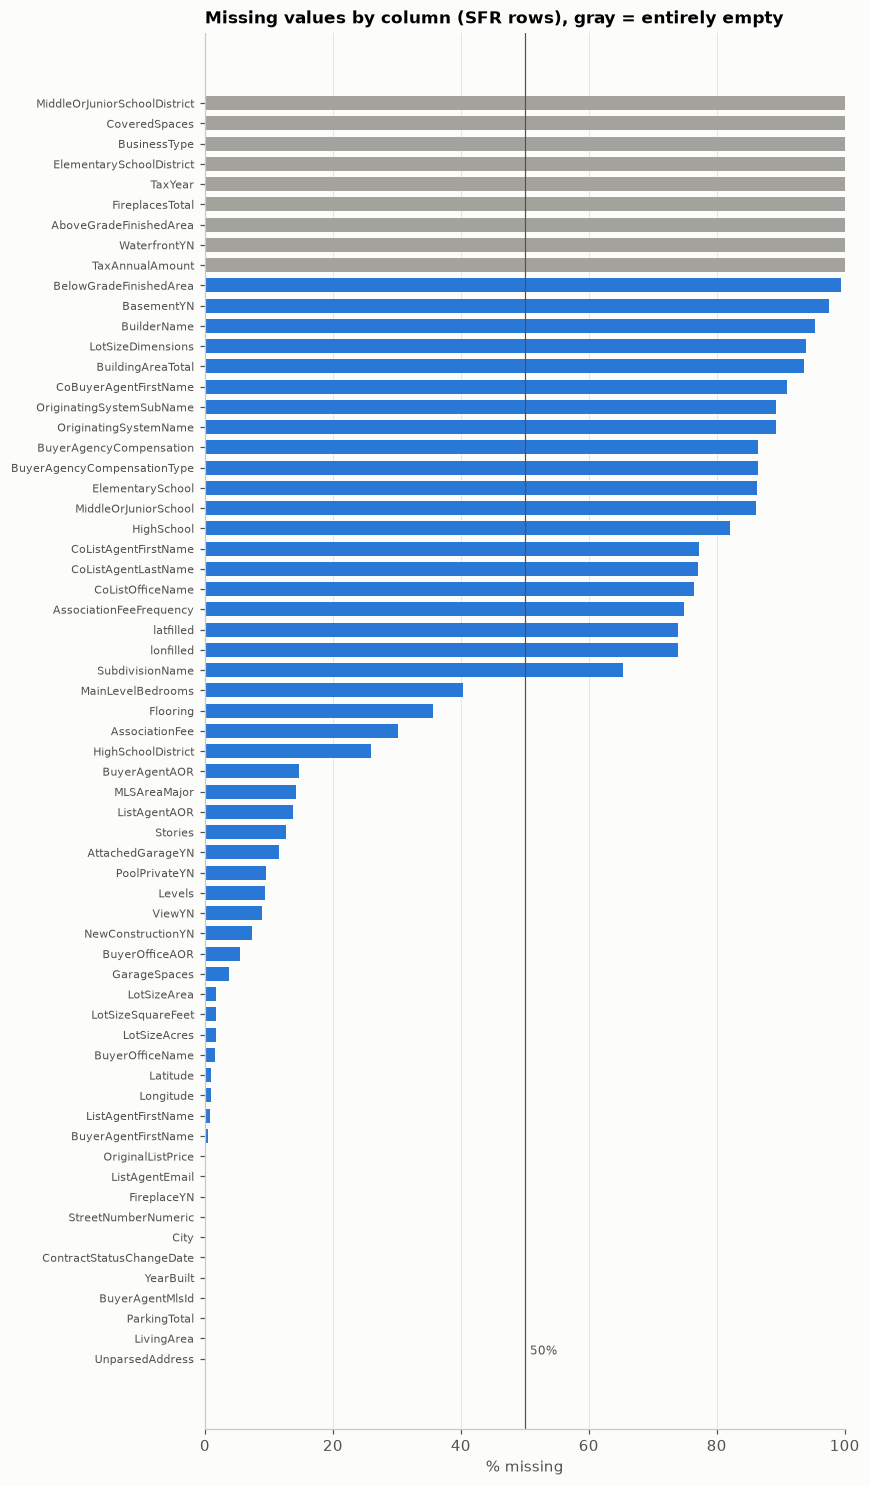

Entirely empty columns: WaterfrontYN, FireplacesTotal, AboveGradeFinishedArea, TaxAnnualAmount, TaxYear, ElementarySchoolDistrict, BusinessType, CoveredSpaces, MiddleOrJuniorSchoolDistrict


In [33]:
miss = inventory.loc[inventory['missing_pct'] > 0].sort_values('missing_pct')
fig, ax = plt.subplots(figsize=(8, 0.2 * len(miss) + 1))
ax.barh(miss.index, miss['missing_pct'], color=[GRAY if v == 100 else BLUE for v in miss['missing_pct']], height=0.7)
ax.axvline(50, color='#52514e', lw=0.8)
ax.text(50.8, 0.2, '50%', color='#52514e', fontsize=8)
ax.set_title('Missing values by column (SFR rows), gray = entirely empty')
ax.set_xlabel('% missing')
ax.set_xlim(0, 100)
ax.tick_params(axis='y', labelsize=7.5)
ax.grid(axis='y', visible=False)
plt.tight_layout()
save_fig('missing_values')
plt.show()

print('Entirely empty columns:', ', '.join(inventory.index[inventory['missing_pct'] == 100]))

Missingness is not random. Some is caused by the schema differences in Section 1 (a column absent from a file is 100% missing for that month), and some looks systematic. The table below shows the missing rate per closing year for a few fields worth watching.

In [34]:
watch = ['LotSizeSquareFeet', 'Latitude', 'GarageSpaces', 'Stories', 'PoolPrivateYN', 'ViewYN',
         'AssociationFee', 'MainLevelBedrooms', 'HighSchoolDistrict', 'SubdivisionName']
(100 * sfr.groupby(sfr['CloseDate'].dt.year)[watch].agg(lambda s: s.isna().mean())).round(1).T

CloseDate,2024,2025,2026
LotSizeSquareFeet,1.70,1.70,1.90
Latitude,1.80,0.00,0.50
GarageSpaces,3.50,4.00,3.80
Stories,15.10,10.80,10.50
PoolPrivateYN,11.80,7.90,7.60
ViewYN,8.90,9.10,8.40
AssociationFee,31.60,29.30,28.30
MainLevelBedrooms,41.60,39.20,39.10
HighSchoolDistrict,25.00,26.80,27.10
SubdivisionName,66.10,64.80,64.30


## 4. Data quality checks

These are records that "cannot be true" or look suspicious (AVM best practice 02). Each check is a boolean mask; counts are reported against the SFR total. **Nothing is removed yet**: the cleaning rules and their logged row counts are a Week 3 deliverable, and percentile-based outlier cutoffs must come from the training window only.

In [35]:
cp, la = sfr['ClosePrice'], sfr['LivingArea']
close_year = sfr['CloseDate'].dt.year
lot_ratio = sfr['LotSizeSquareFeet'] / (sfr['LotSizeAcres'] * 43560)

checks = {
    'ClosePrice missing or <= 0': cp.isna() | (cp <= 0),
    'ClosePrice < $10K': cp.between(0, 10_000, inclusive='neither'),
    'ClosePrice > $50M': cp > 50e6,
    'LivingArea missing or <= 0': la.isna() | (la <= 0),
    'LivingArea < 300 sqft (> 0)': la.between(0, 300, inclusive='neither'),
    'LivingArea > 20,000 sqft': la > 20_000,
    'Price per sqft < $50': sfr['PricePerSqft'] < 50,
    'Price per sqft > $5,000': sfr['PricePerSqft'] > 5_000,
    'BedroomsTotal == 0': sfr['BedroomsTotal'] == 0,
    'BathroomsTotalInteger == 0': sfr['BathroomsTotalInteger'] == 0,
    'Bedrooms > 15 or Bathrooms > 15': (sfr['BedroomsTotal'] > 15) | (sfr['BathroomsTotalInteger'] > 15),
    'YearBuilt < 1850 or after close year': (sfr['YearBuilt'] < 1850) | (sfr['YearBuilt'] > close_year + 1),
    'CloseDate before ListingContractDate': sfr['CloseDate'] < sfr['ListingContractDate'],
    'CloseDate before PurchaseContractDate': sfr['CloseDate'] < sfr['PurchaseContractDate'],
    'DaysOnMarket < 0': sfr['DaysOnMarket'] < 0,
    'Latitude/Longitude missing': sfr['Latitude'].isna() | sfr['Longitude'].isna(),
    'Coordinates outside California': sfr['Latitude'].notna() & ~(
        sfr['Latitude'].between(*CA_LAT) & sfr['Longitude'].between(*CA_LON)),
    'StateOrProvince != CA': sfr['StateOrProvince'] != 'CA',
    'LotSizeSquareFeet and LotSizeAcres disagree (>1%)': (lot_ratio - 1).abs() > 0.01,
    'Exact duplicate row': sfr.drop(columns='SourceMonth').duplicated(keep='first'),
    'ListingKey seen more than once': sfr['ListingKey'].duplicated(keep=False),
}
qc = pd.DataFrame({'rows_flagged': {k: int(v.sum()) for k, v in checks.items()}})
qc['pct_of_sfr'] = (100 * qc['rows_flagged'] / len(sfr)).round(3)
any_flag = np.logical_or.reduce([v.fillna(False).to_numpy() for v in checks.values()])
print(f'Rows hitting at least one check: {any_flag.sum():,} ({pct(any_flag.sum(), len(sfr))})')
qc

Rows hitting at least one check: 4,919 (1.59%)


,rows_flagged,pct_of_sfr
ClosePrice missing or <= 0,3,0.00
ClosePrice < $10K,7,0.00
ClosePrice > $50M,31,0.01
LivingArea missing or <= 0,292,0.09
LivingArea < 300 sqft (> 0),25,0.01
"LivingArea > 20,000 sqft",13,0.00
Price per sqft < $50,139,0.04
"Price per sqft > $5,000",114,0.04
BedroomsTotal == 0,176,0.06
BathroomsTotalInteger == 0,132,0.04


A closer look at repeated `ListingKey`s. `ListingKey` is the primary key in Trestle, so a key appearing twice means the same listing was reported closed in more than one monthly pull. Some are exact copies; others carry a different close date or price, which looks like a correction or a re-recorded sale.

In [36]:
dup = sfr[sfr['ListingKey'].duplicated(keep=False)]
g = dup.groupby('ListingKey')
dup_summary = pd.Series({
    'listing keys involved': g.ngroups,
    'rows involved': len(dup),
    'keys spanning >1 monthly file': int((g['SourceMonth'].nunique() > 1).sum()),
    'keys with differing ClosePrice': int((g['ClosePrice'].nunique() > 1).sum()),
    'keys with differing CloseDate': int((g['CloseDate'].nunique() > 1).sum()),
})
dup_summary.to_frame('count')

,count
listing keys involved,260
rows involved,524
keys spanning >1 monthly file,231
keys with differing ClosePrice,59
keys with differing CloseDate,231


## 5. Target: `ClosePrice`

Summary statistics include the 0.5th and 99.5th percentiles, the cutoffs the best-practices guide prescribes for outlier trimming. They are computed here on all 28 months for orientation only. In Week 3 they must be computed on the training window and frozen before touching the test month.

In [37]:
valid_price = sfr.loc[sfr['ClosePrice'] > 0, 'ClosePrice']
q = valid_price.quantile([0, .005, .01, .05, .25, .5, .75, .95, .99, .995, 1])
q.index = [f'p{100 * i:g}' for i in q.index]
summary = pd.concat([pd.Series({'count': len(valid_price), 'mean': valid_price.mean(),
                                'skew': valid_price.skew()}), q])
summary.to_frame('ClosePrice')

,ClosePrice
count,"309,732.00"
mean,"1,297,557.31"
skew,132.11
p0,1.15
p0.5,"190,000.00"
p1,"237,624.00"
p5,"367,000.00"
p25,"625,000.00"
p50,"894,000.00"
p75,"1,430,000.00"


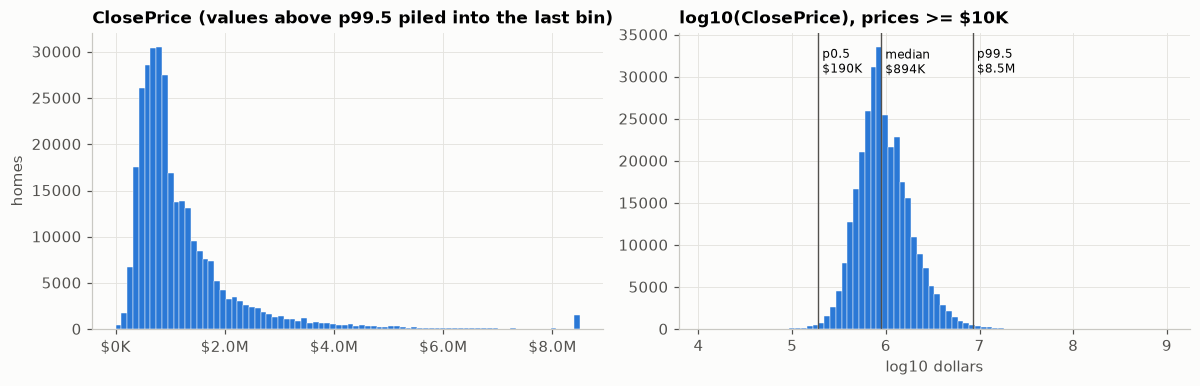

Skew raw: 132.1   skew of log10: 0.55


In [38]:
lo, hi = valid_price.quantile([.005, .995])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].hist(valid_price.clip(upper=hi), bins=80, color=BLUE, edgecolor='#fcfcfb', linewidth=0.3)
axes[0].set_title('ClosePrice (values above p99.5 piled into the last bin)')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(money))
axes[0].set_ylabel('homes')

axes[1].hist(np.log10(valid_price[valid_price >= 1e4]), bins=80, color=BLUE, edgecolor='#fcfcfb', linewidth=0.3)
for v, lbl in [(lo, 'p0.5'), (valid_price.median(), 'median'), (hi, 'p99.5')]:
    axes[1].axvline(np.log10(v), color='#52514e', lw=0.9)
    axes[1].text(np.log10(v), axes[1].get_ylim()[1] * 0.95, f' {lbl}\n {money(v)}', fontsize=8, va='top')
axes[1].set_title('log10(ClosePrice), prices >= $10K')
axes[1].set_xlabel('log10 dollars')
plt.tight_layout()
save_fig('close_price_distribution')
plt.show()

print(f'Skew raw: {valid_price.skew():.1f}   skew of log10: {np.log10(valid_price[valid_price >= 1e4]).skew():.2f}')

## 6. Core features

The task asks specifically about `LivingArea`, `BedroomsTotal`, `BathroomsTotalInteger` and lot size. `YearBuilt` and price per square foot are added because property age and $/sqft come up again in feature engineering and outlier checks. For lot size, `LotSizeSquareFeet` is used; Section 4 showed it mostly agrees with `LotSizeAcres` x 43,560.

In [39]:
core = ['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet',
        'YearBuilt', 'PricePerSqft']
sfr[core].describe(percentiles=[.005, .25, .5, .75, .995]).T

,count,mean,std,min,0.5%,25%,50%,75%,99.5%,max
ClosePrice,"309,733.00","1,297,553.12","5,643,292.57",0.00,"190,000.00","625,000.00","894,000.00","1,430,000.00","8,498,340.00","989,500,000.00"
LivingArea,"309,569.00","2,033.88","1,058.30",0.00,638.00,"1,376.00","1,804.00","2,421.00","6,745.32","123,764.00"
BedroomsTotal,"309,735.00",3.48,0.96,0.00,1.00,3.00,3.00,4.00,6.00,45.00
BathroomsTotalInteger,"309,685.00",2.62,1.20,0.00,1.00,2.00,2.00,3.00,7.00,175.00
LotSizeSquareFeet,"304,408.00","266,665.18","14,602,826.47",0.00,"1,356.04","5,663.00","7,245.00","10,350.00","477,669.87","2,087,220,960.00"
YearBuilt,"309,510.00","1,975.63",27.50,"1,776.00","1,906.00","1,956.00","1,976.00","1,998.00","2,025.00","2,026.00"
PricePerSqft,"309,441.00",639.21,"4,303.28",0.00,145.00,348.26,532.71,751.19,"2,295.51","1,164,066.85"


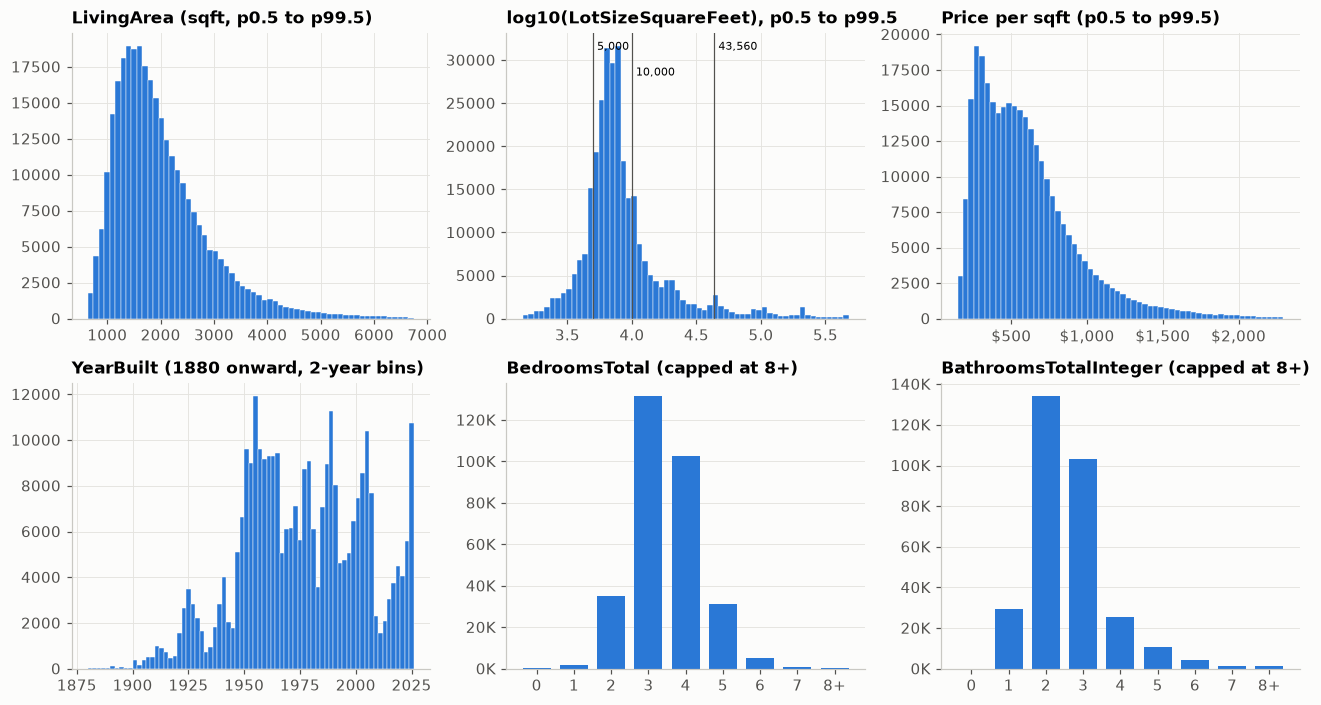

In [40]:
def clipped(s, lo=.005, hi=.995):
    s = s.dropna()
    return s[s.between(*s.quantile([lo, hi]))]

fig, axes = plt.subplots(2, 3, figsize=(12, 6.5))
hist_kw = dict(bins=60, color=BLUE, edgecolor='#fcfcfb', linewidth=0.3)

axes[0, 0].hist(clipped(sfr['LivingArea']), **hist_kw)
axes[0, 0].set_title('LivingArea (sqft, p0.5 to p99.5)')

axes[0, 1].hist(np.log10(clipped(sfr.loc[sfr['LotSizeSquareFeet'] > 0, 'LotSizeSquareFeet'])), **hist_kw)
axes[0, 1].set_title('log10(LotSizeSquareFeet), p0.5 to p99.5')
for v in [5_000, 10_000, 43_560]:
    axes[0, 1].axvline(np.log10(v), color='#52514e', lw=0.8)
for v, y in [(5_000, 0.97), (10_000, 0.88), (43_560, 0.97)]:
    axes[0, 1].text(np.log10(v), axes[0, 1].get_ylim()[1] * y, f' {v:,}', fontsize=7.5, va='top')

axes[0, 2].hist(clipped(sfr['PricePerSqft']), **hist_kw)
axes[0, 2].set_title('Price per sqft (p0.5 to p99.5)')
axes[0, 2].xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

yb = sfr['YearBuilt'].dropna()
axes[1, 0].hist(yb[yb >= 1880], bins=range(1880, 2028, 2), color=BLUE, edgecolor='#fcfcfb', linewidth=0.3)
axes[1, 0].set_title('YearBuilt (1880 onward, 2-year bins)')

for ax, col, cap, title in [(axes[1, 1], 'BedroomsTotal', 8, 'BedroomsTotal'),
                            (axes[1, 2], 'BathroomsTotalInteger', 8, 'BathroomsTotalInteger')]:
    vc = sfr[col].dropna().clip(upper=cap).astype(int).value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color=BLUE, width=0.75)
    ax.set_xticks(range(len(vc)), [f'{i}+' if i == cap else str(i) for i in vc.index])
    ax.set_title(f'{title} (capped at {cap}+)')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x / 1e3:.0f}K'))
    ax.grid(axis='x', visible=False)

plt.tight_layout()
save_fig('core_features')
plt.show()

## 7. Relationships with `ClosePrice`

Living area is the obvious first driver. A log-log hexbin keeps 300K points readable and shows whether the relationship is roughly linear on that scale (which would suggest log-transforming target and size for the Week 4 linear baseline).

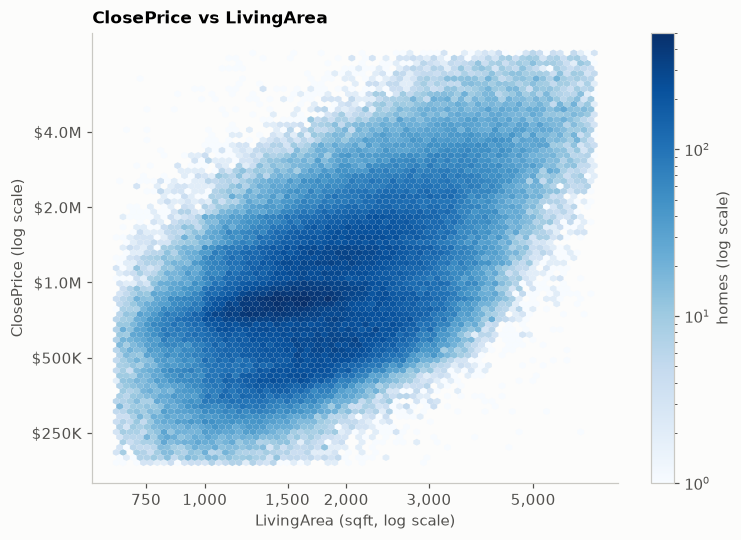

Spearman rho (LivingArea, ClosePrice): 0.488
Pearson r on log10 scale: 0.542


In [41]:
pl = sfr[(sfr['ClosePrice'] >= 1e4) & (sfr['LivingArea'] > 0)]
pl = pl[pl['ClosePrice'].between(*pl['ClosePrice'].quantile([.005, .995]))
        & pl['LivingArea'].between(*pl['LivingArea'].quantile([.005, .995]))]

fig, ax = plt.subplots(figsize=(7, 5))
hb = ax.hexbin(np.log10(pl['LivingArea']), np.log10(pl['ClosePrice']), gridsize=70, cmap='Blues',
               bins='log', mincnt=1, linewidths=0)
fig.colorbar(hb, ax=ax, label='homes (log scale)')
xt = [750, 1000, 1500, 2000, 3000, 5000]
yt = [250e3, 500e3, 1e6, 2e6, 4e6]
ax.set_xticks(np.log10(xt), [f'{v:,}' for v in xt])
ax.set_yticks(np.log10(yt), [money(v) for v in yt])
ax.set_xlabel('LivingArea (sqft, log scale)')
ax.set_ylabel('ClosePrice (log scale)')
ax.set_title('ClosePrice vs LivingArea')
ax.grid(False)
plt.tight_layout()
save_fig('price_vs_living_area')
plt.show()

print('Spearman rho (LivingArea, ClosePrice):', round(pl['LivingArea'].corr(pl['ClosePrice'], method='spearman'), 3))
print('Pearson r on log10 scale:', round(np.log10(pl['LivingArea']).corr(np.log10(pl['ClosePrice'])), 3))

BedroomsTotal {0: 60, 1: 1009, 2: 33830, 3: 130765, 4: 102273, 5: 30545, 6: 4644, 7: 1037}
BathroomsTotalInteger {0: 58, 1: 27012, 2: 133377, 3: 102936, 4: 25028, 5: 10580, 6: 5125}


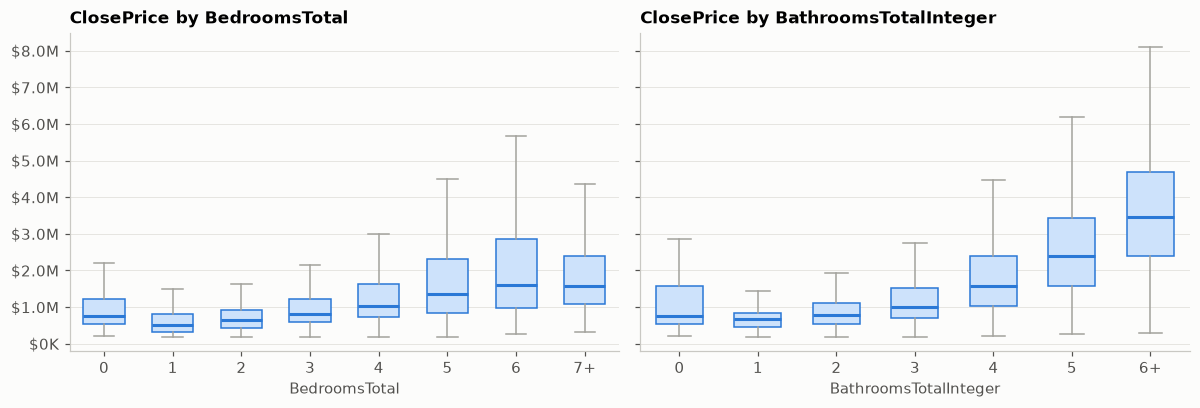

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
box_kw = dict(showfliers=False, patch_artist=True, widths=0.6,
              boxprops=dict(facecolor='#cde2fb', edgecolor=BLUE, linewidth=1),
              medianprops=dict(color=BLUE, linewidth=2),
              whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY))

for ax, col, cap in [(axes[0], 'BedroomsTotal', 7), (axes[1], 'BathroomsTotalInteger', 6)]:
    d = pl.dropna(subset=[col]).assign(k=lambda x: x[col].clip(upper=cap).astype(int))
    levels = sorted(d['k'].unique())
    ax.boxplot([d.loc[d['k'] == k, 'ClosePrice'] for k in levels], **box_kw)
    ax.set_xticks(range(1, len(levels) + 1), [f'{k}+' if k == cap else str(k) for k in levels])
    ax.set_title(f'ClosePrice by {col}')
    ax.set_xlabel(col)
    ax.grid(axis='x', visible=False)
    print(col, d['k'].value_counts().sort_index().to_dict())

axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(money))
plt.tight_layout()
save_fig('price_by_beds_baths')
plt.show()

**Correlation screen and first leakage check.** Spearman (rank) correlation is used because prices and sizes are heavily skewed. `ListPrice`, `OriginalListPrice` and `DaysOnMarket` are included on purpose to show why the best-practices guide excludes them: list price is nearly the answer itself and is unavailable for off-market homes.

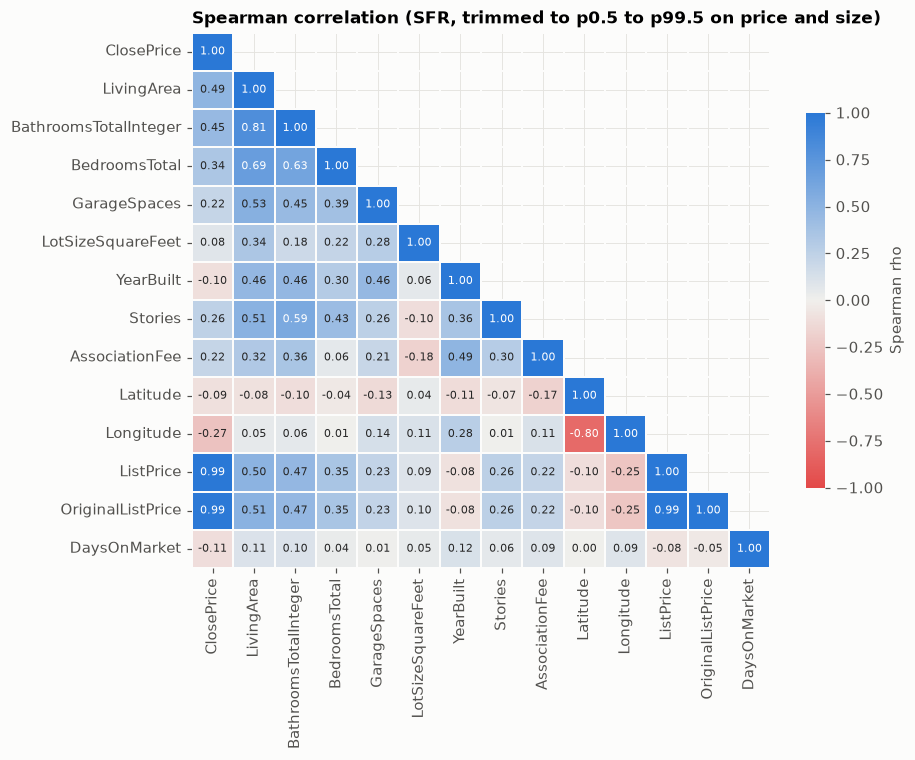

In [43]:
corr_cols = ['ClosePrice', 'LivingArea', 'BathroomsTotalInteger', 'BedroomsTotal', 'GarageSpaces',
             'LotSizeSquareFeet', 'YearBuilt', 'Stories', 'AssociationFee', 'Latitude', 'Longitude',
             'ListPrice', 'OriginalListPrice', 'DaysOnMarket']
corr = pl[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8.5, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap=sns.blend_palette(['#e34948', '#f0efec', '#2a78d6'], as_cmap=True),
            vmin=-1, vmax=1, center=0, annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=1, linecolor='#fcfcfb', cbar_kws={'label': 'Spearman rho', 'shrink': 0.7}, ax=ax)
ax.set_title('Spearman correlation (SFR, trimmed to p0.5 to p99.5 on price and size)')
plt.tight_layout()
save_fig('correlation_heatmap')
plt.show()

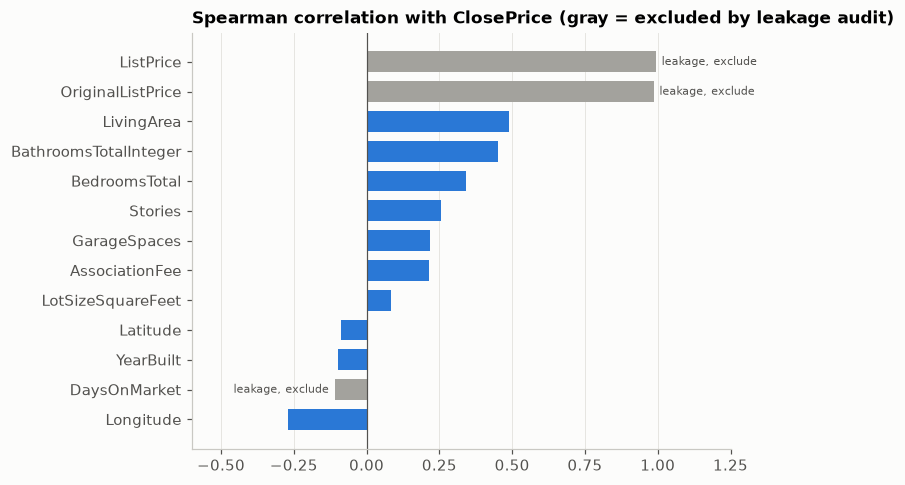

In [44]:
leak = {'ListPrice', 'OriginalListPrice', 'DaysOnMarket'}
target_corr = corr['ClosePrice'].drop('ClosePrice').sort_values()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(target_corr.index, target_corr.values, height=0.7,
        color=[GRAY if c in leak else BLUE for c in target_corr.index])
ax.axvline(0, color='#52514e', lw=0.8)
for i, (c, v) in enumerate(target_corr.items()):
    if c in leak:
        ax.text(v + (0.02 if v >= 0 else -0.02), i, 'leakage, exclude', va='center',
                ha='left' if v >= 0 else 'right', fontsize=7.5, color='#52514e')
ax.set_xlim(-0.6, 1.25)
ax.set_title('Spearman correlation with ClosePrice (gray = excluded by leakage audit)')
ax.grid(axis='y', visible=False)
plt.tight_layout()
save_fig('correlation_with_price')
plt.show()

Boolean amenity flags. Medians are compared with and without each feature; differences here mix the feature's own effect with where such homes are located (pools and views cluster in pricier areas), so these are descriptive, not causal.

In [45]:
rows = []
for c in ['PoolPrivateYN', 'ViewYN', 'AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN']:
    s = pl[c]
    rows.append({
        'feature': c,
        'pct_true': round(100 * (s == True).mean(), 1),
        'pct_missing': round(100 * s.isna().mean(), 1),
        'median_price_true': pl.loc[s == True, 'ClosePrice'].median(),
        'median_price_false': pl.loc[s == False, 'ClosePrice'].median(),
        'median_ppsf_true': pl.loc[s == True, 'PricePerSqft'].median(),
        'median_ppsf_false': pl.loc[s == False, 'PricePerSqft'].median(),
    })
pd.DataFrame(rows).set_index('feature')

,pct_true,pct_missing,median_price_true,median_price_false,median_ppsf_true,median_ppsf_false
feature,,,,,,
PoolPrivateYN,14.60,9.50,"1,100,000.00","825,000.00",498.49,508.95
ViewYN,54.70,9.00,"900,000.00","868,225.00",497.08,564.07
AttachedGarageYN,74.20,11.10,"895,000.00","890,000.00",499.41,642.14
FireplaceYN,72.90,0.10,"1,000,000.00","720,000.00",542.25,500.00
NewConstructionYN,3.60,7.30,"644,995.00","895,000.00",308.21,537.58


## 8. Geography

Location usually explains most of what size does not. Counties are compared on median price and median $/sqft (which partly controls for home size), restricted to the 15 counties with the most sales.

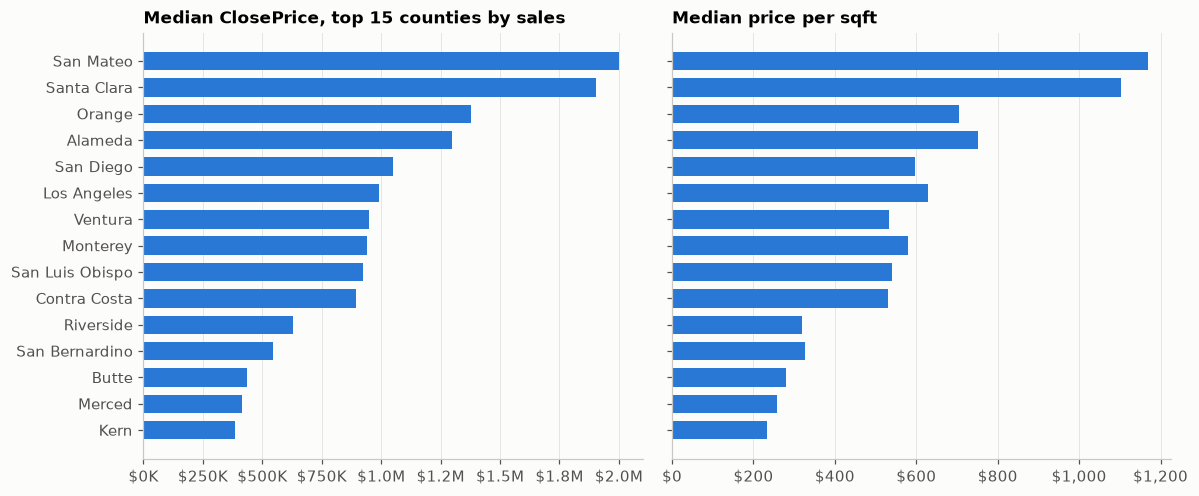

,sales,median_price,median_ppsf
CountyOrParish,,,
Los Angeles,73371,"990,000.00",627.58
Riverside,46493,"630,000.00",320.34
San Diego,32959,"1,050,000.00",595.81
San Bernardino,32258,"547,000.00",326.39
Orange,28575,"1,380,000.00",704.48
Alameda,14731,"1,300,000.00",752.41
Contra Costa,14345,"895,000.00",530.06
Santa Clara,12518,"1,903,250.00","1,102.24"
Ventura,9548,"950,000.00",532.17


In [46]:
top = sfr['CountyOrParish'].value_counts().head(15).index
by_county = (pl[pl['CountyOrParish'].isin(top)]
             .groupby('CountyOrParish')
             .agg(sales=('ClosePrice', 'size'), median_price=('ClosePrice', 'median'),
                  median_ppsf=('PricePerSqft', 'median'))
             .sort_values('median_price'))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
axes[0].barh(by_county.index, by_county['median_price'], color=BLUE, height=0.7)
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(money))
axes[0].set_title('Median ClosePrice, top 15 counties by sales')
axes[1].barh(by_county.index, by_county['median_ppsf'], color=BLUE, height=0.7)
axes[1].xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
axes[1].set_title('Median price per sqft')
for ax in axes:
    ax.grid(axis='y', visible=False)
plt.tight_layout()
save_fig('county_prices')
plt.show()

by_county.sort_values('sales', ascending=False)

The map below shows median $/sqft in small hexagonal cells. To make it easier to see which places the expensive cells are, the right panel shows a street map of exactly the same area (Esri World Street Map tiles, downloaded when the cell runs, so this cell needs an internet connection). Both panels use the Web Mercator projection that web maps use, so they line up point for point.

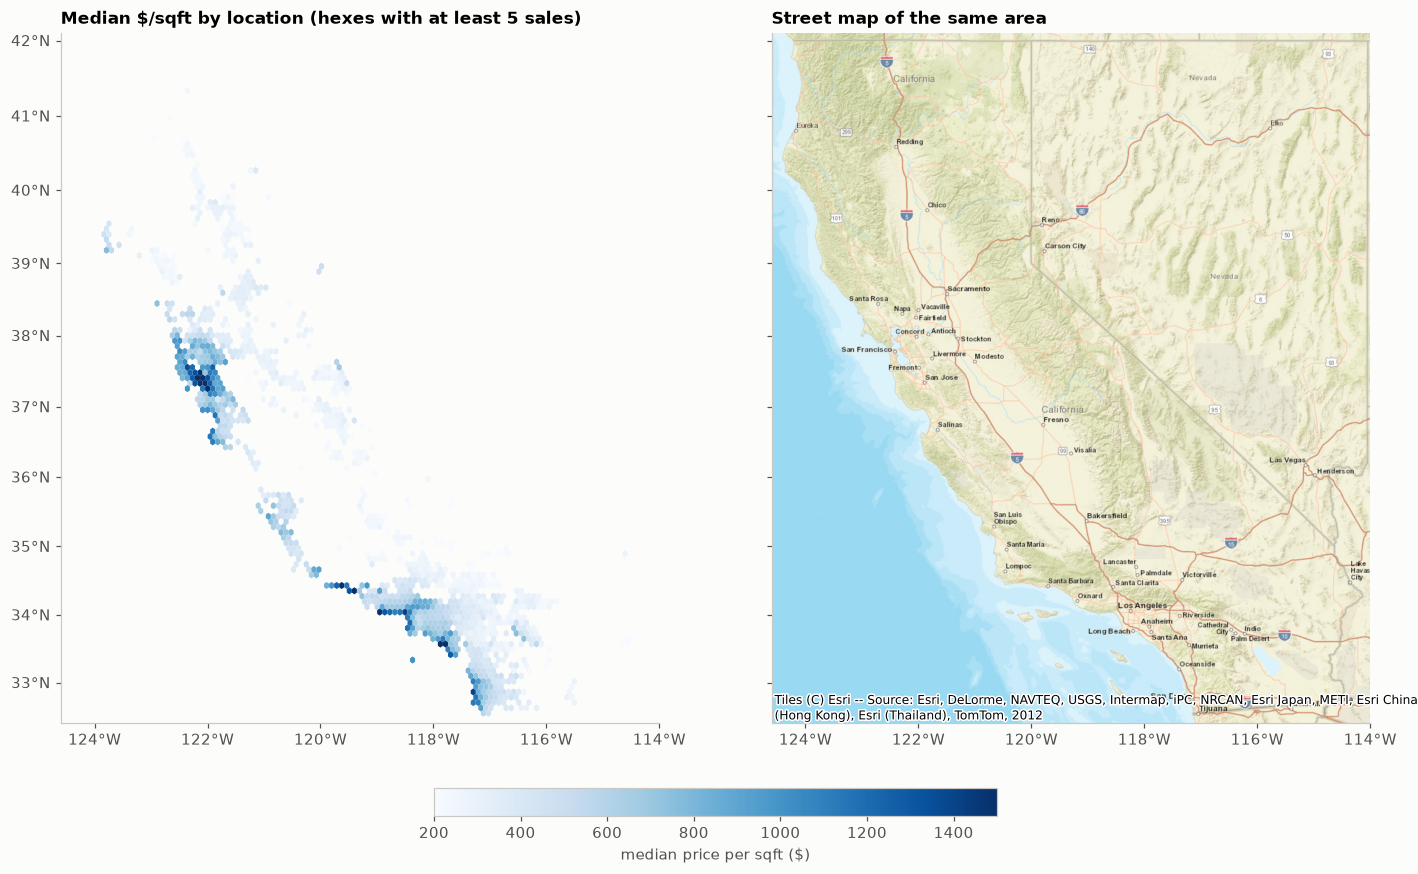

301,410 of 304,163 trimmed rows have usable coordinates; 62 counties, 3,075 postal codes


In [47]:
geo = pl[pl['Latitude'].between(*CA_LAT) & pl['Longitude'].between(*CA_LON)]

R_EARTH = 6_378_137  # sphere radius (meters) used by the Web Mercator projection


def to_web_mercator(lon, lat):
    # Degrees -> Web Mercator meters, the coordinates map tiles are drawn in
    return np.radians(lon) * R_EARTH, R_EARTH * np.log(np.tan(np.pi / 4 + np.radians(lat) / 2))


gx, gy = to_web_mercator(geo['Longitude'].to_numpy(), geo['Latitude'].to_numpy())
x0, y0 = to_web_mercator(CA_LON[0], CA_LAT[0])
x1, y1 = to_web_mercator(CA_LON[1], CA_LAT[1])

fig, axes = plt.subplots(1, 2, figsize=(13, 7.8), sharex=True, sharey=True, layout='constrained')
hb = axes[0].hexbin(gx, gy, C=geo['PricePerSqft'], reduce_C_function=np.median, gridsize=110,
                    cmap='Blues', mincnt=5, vmin=200, vmax=1500, linewidths=0)
axes[0].set_title('Median $/sqft by location (hexes with at least 5 sales)')
axes[1].set_title('Street map of the same area')

lon_ticks, lat_ticks = np.arange(-124, -113, 2), np.arange(33, 43)
for ax in axes:
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.set_aspect('equal')
    ax.grid(False)
    ax.set_xticks(to_web_mercator(lon_ticks, 35)[0], [f'{-v}°W' for v in lon_ticks])
    ax.set_yticks(to_web_mercator(-120, lat_ticks)[1], [f'{v}°N' for v in lat_ticks])

ctx.add_basemap(axes[1], source=ctx.providers.Esri.WorldStreetMap, zoom=7)
fig.colorbar(hb, ax=axes, location='bottom', shrink=0.4, label='median price per sqft ($)')
save_fig('price_per_sqft_map')
plt.show()

print(f"{len(geo):,} of {len(pl):,} trimmed rows have usable coordinates; "
      f"{geo['CountyOrParish'].nunique()} counties, {geo['PostalCode'].nunique():,} postal codes")

## 9. Time trends and seasonality

The model will be evaluated chronologically (train on earlier months, test on the most recent month), so it matters whether prices drift and whether volume and mix change with the season. Volume and price are on separate panels rather than a dual axis.

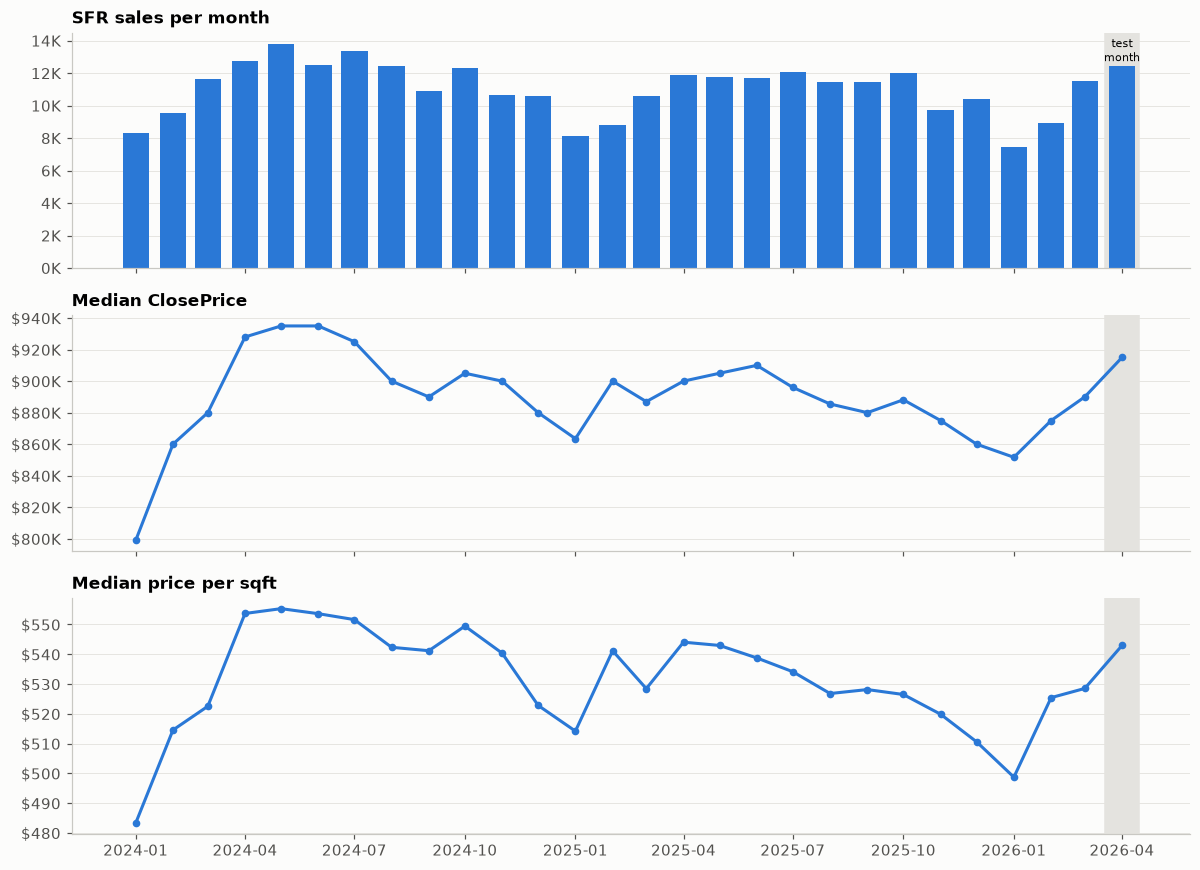

,sales,median_price,median_ppsf,median_sqft
CloseMonth,,,,
2025-11,9739,"875,000.00",519.86,"1,812.00"
2025-12,10455,"860,000.00",510.58,"1,804.00"
2026-01,7490,"851,691.50",498.73,"1,821.00"
2026-02,8959,"875,000.00",525.43,"1,823.50"
2026-03,11562,"890,000.00",528.52,"1,821.00"
2026-04,12490,"915,000.00",542.95,"1,833.00"


In [48]:
monthly = (sfr[sfr['ClosePrice'] > 0]
           .groupby('CloseMonth')
           .agg(sales=('ClosePrice', 'size'), median_price=('ClosePrice', 'median'),
                median_ppsf=('PricePerSqft', 'median'), median_sqft=('LivingArea', 'median')))
x = monthly.index.to_timestamp()

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
axes[0].bar(x, monthly['sales'], width=22, color=BLUE)
axes[0].set_title('SFR sales per month')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v / 1e3:.0f}K'))

axes[1].plot(x, monthly['median_price'], color=BLUE, lw=2, marker='o', ms=4)
axes[1].set_title('Median ClosePrice')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(money))

axes[2].plot(x, monthly['median_ppsf'], color=BLUE, lw=2, marker='o', ms=4)
axes[2].set_title('Median price per sqft')
axes[2].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

for ax in axes:
    ax.grid(axis='x', visible=False)
# Shade the most recent month: the Week 3 test set
for ax in axes:
    ax.axvspan(x[-1] - pd.Timedelta(days=14), x[-1] + pd.Timedelta(days=14), color=LIGHT_GRAY, zorder=0)
axes[0].text(x[-1], axes[0].get_ylim()[1] * 0.98, 'test\nmonth', ha='center', va='top', fontsize=7.5)
plt.tight_layout()
save_fig('monthly_trends')
plt.show()

monthly.tail(6)

In [49]:
by_moy = sfr[sfr['ClosePrice'] > 0].groupby(sfr['CloseDate'].dt.month).agg(
    avg_monthly_sales=('ClosePrice', lambda s: len(s) / sfr.loc[s.index, 'CloseDate'].dt.year.nunique()),
    median_price=('ClosePrice', 'median'))
by_moy.index = pd.to_datetime(by_moy.index, format='%m').strftime('%b')

yoy = monthly['median_price'].pct_change(12).dropna()
print('Year-over-year change in monthly median ClosePrice (%):')
print((100 * yoy).round(1).to_string())
by_moy

Year-over-year change in monthly median ClosePrice (%):
CloseMonth
2025-01    8.10
2025-02    4.70
2025-03    0.80
2025-04   -3.00
2025-05   -3.20
2025-06   -2.70
2025-07   -3.10
2025-08   -1.60
2025-09   -1.10
2025-10   -1.90
2025-11   -2.80
2025-12   -2.30
2026-01   -1.40
2026-02   -2.80
2026-03    0.30
2026-04    1.70
Freq: M


,avg_monthly_sales,median_price
CloseDate,,
Jan,"7,985.33","835,000.00"
Feb,"9,124.67","878,500.00"
Mar,"11,268.67","885,000.00"
Apr,"12,371.67","915,000.00"
May,"12,804.00","923,000.00"
Jun,"12,122.50","925,000.00"
Jul,"12,745.50","910,000.00"
Aug,"11,943.50","895,000.00"
Sep,"11,182.50","885,000.00"


**Sale-to-list ratio (context only).** `ClosePrice / ListPrice` is the market-heat indicator from the primer. It cannot be a model feature (it contains the target), but it shows how close list price sits to the answer, which is the reason `ListPrice` is excluded.

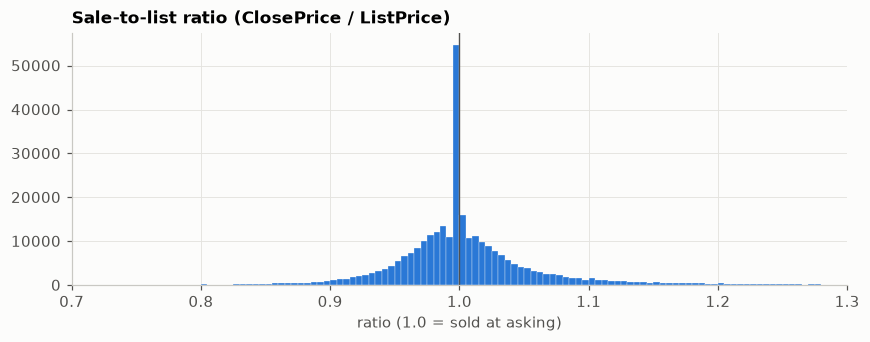

Median ratio 1.000; within +/-5% of asking: 74.66%; above asking: 42.93%


In [50]:
stl = (pl['ClosePrice'] / pl['ListPrice']).replace([np.inf, -np.inf], np.nan).dropna()
stl = stl[stl.between(0.5, 1.5)]
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(stl, bins=np.arange(0.7, 1.3, 0.005), color=BLUE, edgecolor='#fcfcfb', linewidth=0.2)
ax.axvline(1, color='#52514e', lw=0.9)
ax.set_title('Sale-to-list ratio (ClosePrice / ListPrice)')
ax.set_xlabel('ratio (1.0 = sold at asking)')
ax.set_xlim(0.7, 1.3)
plt.tight_layout()
save_fig('sale_to_list')
plt.show()
print(f'Median ratio {stl.median():.3f}; within +/-5% of asking: {pct(stl.between(.95, 1.05).sum(), len(stl))}; '
      f'above asking: {pct((stl > 1).sum(), len(stl))}')

## 10. Key findings and next steps

Numbers below come from the outputs above (all 28 months, SFR only).

**Data and scope**
- 28 monthly files hold 615,707 closed records; 309,735 (50.3%) are Residential single-family. Every row's `CloseDate` falls inside its file's month, so the files split cleanly by close month, which makes the chronological split straightforward.
- The schema drifts between files: 8 columns exist only in some months (Section 1). The Week 3 loader must align columns explicitly. `BuyerAgencyCompensation` only exists January to April 2024, which fits the 2024 NAR settlement change described in the primer.
- 9 columns are completely empty for SFR (including `TaxAnnualAmount`, `TaxYear` and the elementary and middle school district columns) and can be dropped. About 20 more are over 50% missing.

**Data quality**
- 4,919 rows (1.6%) hit at least one check. The largest groups: missing coordinates (2,712), lot size in square feet disagreeing with acres (605), repeated `ListingKey`s (524 rows) and zero or missing living area (292).
- Clear entry errors exist at both ends: a minimum `ClosePrice` of $1.15 and a maximum of $989.5M, 123,764 sqft of living area, 175 bathrooms, a 2.1 billion sqft lot, and coordinates outside California (some look like swapped latitude and longitude).
- Of the 260 repeated listing keys, 231 show up in two different monthly files with different close dates, and 59 with different prices. Week 3 needs a deduplication rule (keeping the latest record per `ListingKey` is a reasonable default) applied **before** the train/test split, so one sale cannot land in both.

**Target**
- `ClosePrice` is extremely right-skewed (skew 132 raw, 0.55 after log10). Median $894K, interquartile range $625K to $1.43M; p0.5 is $190K and p99.5 is $8.5M over all months. Modeling `log(ClosePrice)` is the natural choice for the linear baseline.

**Features**
- The typical home has 1,804 sqft, 3 beds, 2 baths, a 7,245 sqft lot and was built in 1976. Living area and lot size are right-skewed and are log-transform candidates; lot size has a long rural/acreage tail.
- Living area is the strongest legitimate single correlate (Spearman 0.49), followed by bathrooms (0.45) and bedrooms (0.34). Bedrooms and bathrooms overlap heavily with living area (rho 0.69 and 0.81), so multicollinearity matters for the linear baseline.
- Location matters as much as size. Among the top 15 counties, median $/sqft ranges from $234 (Kern) to $1,168 (San Mateo), a 5x spread, and the map shows the Bay Area and the LA/Orange coast as the expensive clusters. Raw latitude and longitude are weak *linear* correlates, but the signal is clearly non-linear, which favors tree models and engineered location features (county, ZIP-level aggregates fit on train, the Week 6 school-district join).
- Amenity flags are confounded with size and location. Homes with a pool have a higher median price ($1.10M vs $825K) but a slightly lower $/sqft. New construction has a *lower* median price ($645K vs $895K), likely because new single-family supply is mostly in cheaper inland areas.

**Leakage**
- `ListPrice` and `OriginalListPrice` have a Spearman correlation of 0.99 with `ClosePrice`. The median sale-to-list ratio is 1.000 and 75% of homes close within 5% of asking. This confirms the leakage audit: exclude them, along with `DaysOnMarket` and `BuyerAgencyCompensation`.

**Time**
- Strong seasonality: volume bottoms out in January (7,500 to 8,300 SFR sales) and peaks in spring and summer (up to 13,800). Median prices follow, peaking in spring.
- Prices are fairly flat over the window. Year-over-year change in the monthly median ranges from -3.2% to +8.1%, and January 2024 is the low point. Within-county medians also rose from January 2024 to January 2025, so this is not only a change in county mix.
- April 2026, the most recent month and therefore the test month, has 12,490 sales at a $915K median, near the seasonal high. This argues for a month feature (sine/cosine encoded) and for running the rolling-origin backtest at cutoffs in other seasons too.

**Next steps (Week 3, `02_preprocessing.ipynb`)**
1. Align schemas, drop the empty columns, deduplicate on `ListingKey`, and remove impossible records, logging the row count at each step.
2. Chronological split: test = 2026-04, validation = 2026-03, training = the X months before that, with X tuned.
3. Compute the 0.5/99.5 `ClosePrice` percentiles plus a $/sqft sanity check on the training window only, and apply those frozen cutoffs to validation and test.
4. Missingness: pick a drop threshold (about 50%), impute inside a scikit-learn `Pipeline`, and add missing-indicator flags where missingness may be informative (`PoolPrivateYN`, `ViewYN`, `Stories`).
5. Coordinates: fix or impute missing and out-of-state latitude/longitude (for example from postal-code centroids computed on train), or drop those rows.
6. Candidate features: log living area, log lot size, beds, baths, age at sale, garage spaces, stories, pool/view flags, county and ZIP, month sine/cosine.
7. The `CRMLSListing*` files are not used here. They could add market supply/inventory context later.